# 09* — Bray–Curtis NMDS on Relative-Abundance Taxa

## Overview
This notebook performs a **Bray–Curtis NMDS** on the relative-abundance taxa matrix (back-transformed from octave scale) and produces a comprehensive ordination biplot per habitat cluster.

### Pipeline
1. **Data loading & merge** — taxa (octave), pollution scores (Stage 1), cluster labels (Stage 3), waterbody labels.
2. **Octave → Relative Abundance** — inverse-octave + row-normalisation.
3. **Hypothetical endpoints** — reference (5 least-polluted) and degraded (5 most-polluted) site centroids per cluster.
4. **NMDS (2-D)** — Bray–Curtis dissimilarity, non-metric MDS, PCA-rotation for axis alignment.
5. **Visualisation** — a single panel per cluster showing:
   - Sites coloured by **pollution-level bin** (Reference / Test / Degraded) using the 20th and 80th percentile cut-offs.
   - Site **shape** encodes **waterbody** (DR, SCR, LSC).
   - **Endpoint stars** — green ★ = reference, red ★ = degraded.
   - **Species scores** (weighted-average) with labelled arrows.

In [ ]:
# ── §1  Imports & data loading ────────────────────────────────────────────────
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# Project source
SRC = pathlib.Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from zci.io.readers import extract_block
from zci.models.clustering import TAXA_COLUMNS
from zci.core.transforms import octave_to_relative_abundance

try:
    from adjustText import adjust_text
except ModuleNotFoundError:
    adjust_text = None

# ── 1a. Taxa matrix (octave scale) ───────────────────────────────────────────
DATA_PATH = "../data/processed/complete_env_taxa_chemical_Feb_3.xlsx"
data = pd.read_excel(DATA_PATH, header=[0, 1, 2], index_col=0)
taxa_all = extract_block(data, "taxa", "raw")[list(TAXA_COLUMNS)]
print(f"taxa_all shape: {taxa_all.shape}")

# ── 1b. Pollution scores (Stage 1) ───────────────────────────────────────────
STAGE1_PATH = "../results/01_pollution_assessment/artifacts/01_updated_data.xlsx"
stage1 = pd.read_excel(STAGE1_PATH, header=[0, 1, 2], index_col=0)
pollution_score = stage1.loc[:, ("01_pollution_assessment", "raw", "Pollution_Score")]
pollution_score.name = "Pollution_Score"

# ── 1c. Cluster labels + reference flag (Stage 3, LDA) ───────────────────────
STAGE3_PATH = "../results/03_LDA_Classification/artifacts/03_updated_data.xlsx"
stage3 = pd.read_excel(STAGE3_PATH, header=[0, 1, 2], index_col=0)
cluster_label = stage3.loc[:, ("03_lda_classification", "raw", "Predicted_Cluster")]
cluster_label.name = "Cluster"
is_reference = stage3.loc[:, ("03_lda_classification", "raw", "Is_Reference")]
is_reference.name = "Is_Reference"

# ── 1d. Waterbody ────────────────────────────────────────────────────────────
sample_info = extract_block(data, "sample_info", "raw")
waterbody_all = sample_info["Waterbody"]
waterbody_all.name = "Waterbody"

# ── 1e. Merge on common index ────────────────────────────────────────────────
site_meta = pd.DataFrame({
    "Pollution_Score": pollution_score,
    "Cluster":         cluster_label.astype(int),
    "Is_Reference":    is_reference.astype(int),
    "Waterbody":       waterbody_all,
})
common_idx = taxa_all.index.intersection(site_meta.dropna().index)
site_meta  = site_meta.loc[common_idx]
taxa       = taxa_all.loc[common_idx]

print(f"Sites retained: {len(common_idx)}")
print(f"Cluster counts:\n{site_meta['Cluster'].value_counts().sort_index()}")
print(f"Waterbody counts:\n{site_meta['Waterbody'].value_counts()}")
print("\nData loading ✓")

taxa_all shape: (233, 16)
Sites retained: 233
Cluster counts:
Cluster
1    204
2     29
Name: count, dtype: int64
Waterbody counts:
Waterbody
DR     146
LSC     67
SCR     20
Name: count, dtype: int64

Data loading ✓


## §2 — Relative Abundance, Endpoints, 2-D NMDS

1. **Octave → Relative abundance**: $p_{ij} = 2^{o_{ij}} - 0.0625$, clipped ≥ 0, then row-normalised.
2. **Endpoints** (per cluster): average the RA taxa vector of the 5 least-polluted sites (reference) and 5 most-polluted sites (degraded).
3. **Augment** the taxa matrix with the two endpoint rows → compute Bray–Curtis → 2-D NMDS (1 000 iterations, 10 random starts).
4. **PCA-rotate** the 2-D solution so NMDS1 captures the largest spread.
5. Optionally **flip NMDS1** so that it is negatively correlated with PS (this makes the later ZCI also tend to be negatively correlated with PS).
6. Compute **weighted-average species scores** on the real sites.

In [2]:
# ── §2  Relative Abundance → Endpoints → 2-D NMDS (per cluster) ──────────────

# 2a. Octave → Relative abundance
taxa_relabd = octave_to_relative_abundance(taxa)
print(f"Relative-abundance matrix: {taxa_relabd.shape}")
print(f"Row sums: min={taxa_relabd.sum(1).min():.4f}, "
      f"max={taxa_relabd.sum(1).max():.4f}")

# Constants
N_EP = 5           # sites averaged per endpoint
clusters = sorted(site_meta["Cluster"].unique())
n_clusters = len(clusters)

# Storage for results
nmds_results = {}  # cl -> dict

for cl in clusters:
    cl_sites = site_meta.index[site_meta["Cluster"] == cl]
    meta_cl  = site_meta.loc[cl_sites]
    taxa_cl  = taxa_relabd.loc[cl_sites]

    # ── 2b. Build endpoints (RA space) ────────────────────────────────────
    ps_sorted = meta_cl["Pollution_Score"].sort_values()
    ref_ids = ps_sorted.index[:N_EP]
    deg_ids = ps_sorted.index[-N_EP:]
    ref_taxa = taxa_cl.loc[ref_ids].mean(axis=0)
    deg_taxa = taxa_cl.loc[deg_ids].mean(axis=0)

    ref_label = f"_REF_EP_{cl}"
    deg_label = f"_DEG_EP_{cl}"

    # Augment taxa matrix with endpoints
    taxa_aug = pd.concat([
        taxa_cl,
        pd.DataFrame([ref_taxa], index=[ref_label], columns=TAXA_COLUMNS),
        pd.DataFrame([deg_taxa], index=[deg_label], columns=TAXA_COLUMNS),
    ])
    print(f"\nCluster {cl}: augmented RA taxa = {taxa_aug.shape}")
    print(f"  REF sites: {ref_ids.tolist()}, mean PS = "
          f"{meta_cl.loc[ref_ids, 'Pollution_Score'].mean():.3f}")
    print(f"  DEG sites: {deg_ids.tolist()}, mean PS = "
          f"{meta_cl.loc[deg_ids, 'Pollution_Score'].mean():.3f}")

    # ── 2c. Bray-Curtis → 2-D NMDS ───────────────────────────────────────
    bc_sq = squareform(pdist(taxa_aug.values, metric="braycurtis"))

    nmds = MDS(
        n_components=2,
        metric=False,
        dissimilarity="precomputed",
        max_iter=1000,
        n_init=10,
        random_state=42,
        normalized_stress="auto",
    )
    coords_arr = nmds.fit_transform(bc_sq)
    stress = nmds.stress_

    # ── 2d. PCA-rotate ────────────────────────────────────────────────────
    pca = PCA(n_components=2).fit(coords_arr)
    coords_arr = pca.transform(coords_arr)
    var_exp = pca.explained_variance_ratio_

    # ── 2e. Flip NMDS1 so corr(NMDS1, PS) < 0 (reference → right) ───────
    #    This heuristic tries to orient the main axis so that later ZCI
    #    (distance-to-degraded / total) will be negatively related to PS.
    real_mask = np.array([i not in (ref_label, deg_label)
                          for i in taxa_aug.index])
    ps_real = meta_cl["Pollution_Score"].values
    r_nmds1, _ = pearsonr(coords_arr[real_mask, 0], ps_real)
    if r_nmds1 > 0:
        coords_arr[:, 0] *= -1
        print(f"  ↳ NMDS1 flipped (raw r={r_nmds1:.3f} > 0)")
    else:
        print(f"  ↳ NMDS1 kept    (raw r={r_nmds1:.3f} ≤ 0)")

    coords_df = pd.DataFrame(coords_arr, index=taxa_aug.index,
                              columns=["NMDS1", "NMDS2"])

    # ── 2f. Weighted-average species scores (real sites only) ─────────────
    real_sites = [s for s in coords_df.index if s not in (ref_label, deg_label)]
    abund = taxa_cl.loc[real_sites].values
    site_coords = coords_df.loc[real_sites].values
    col_sums = abund.sum(axis=0)
    col_sums[col_sums == 0] = 1e-12
    wa = (abund.T @ site_coords) / col_sums[:, None]
    wa_df = pd.DataFrame(wa, index=TAXA_COLUMNS, columns=["WA1", "WA2"])

    nmds_results[cl] = {
        "coords_df":  coords_df,
        "stress":     stress,
        "wa_df":      wa_df,
        "ref_label":  ref_label,
        "deg_label":  deg_label,
        "var_exp":    var_exp,
        "taxa_aug":   taxa_aug,
    }
    print(f"  stress = {stress:.5f}")

print("\n§2 computation done ✓")

Relative-abundance matrix: (233, 16)
Row sums: min=1.0000, max=1.0000

Cluster 1: augmented RA taxa = (206, 16)
  REF sites: ['S38', '075A', 'S65', 'S53', 'S54'], mean PS = 1.582
  DEG sites: ['088C', '007ABC', '081B', '089A', '101C'], mean PS = 3.670


/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


  ↳ NMDS1 kept    (raw r=-0.096 ≤ 0)
  stress = 0.15914

Cluster 2: augmented RA taxa = (31, 16)
  REF sites: ['S17', 'A5', 'S19', 'S12', 'S99'], mean PS = 2.165
  DEG sites: ['091C', '074B', '147A', '052B', '076ABC'], mean PS = 3.502


/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/envThesisProject/lib/python3.13/site-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


  ↳ NMDS1 flipped (raw r=0.316 > 0)
  stress = 0.11429

§2 computation done ✓


## §3 — Comprehensive NMDS Biplot

Each cluster gets a single panel containing:

| Layer | Encoding |
|-------|----------|
| **Sites** | Coloured by **pollution-level bin**: green (Reference, ≤ 20th pctl), grey (Test, 20–80th pctl), red (Degraded, ≥ 80th pctl) |
| **Waterbody** | Marker **shape** — circle (DR), square (SCR), triangle (LSC) |
| **Endpoints** | Large ★ stars — green = reference, red = degraded |
| **Species scores** | Labelled arrows from origin to WA position |
| **Stress** | Reported in the panel title |

Pollution-Score percentiles:  P20 = 2.202,  P80 = 3.136
PS_Bin
Reference     47
Test         139
Degraded      47
Name: count, dtype: int64
Waterbody → marker: {'DR': 'o', 'SCR': 's', 'LSC': '^'}


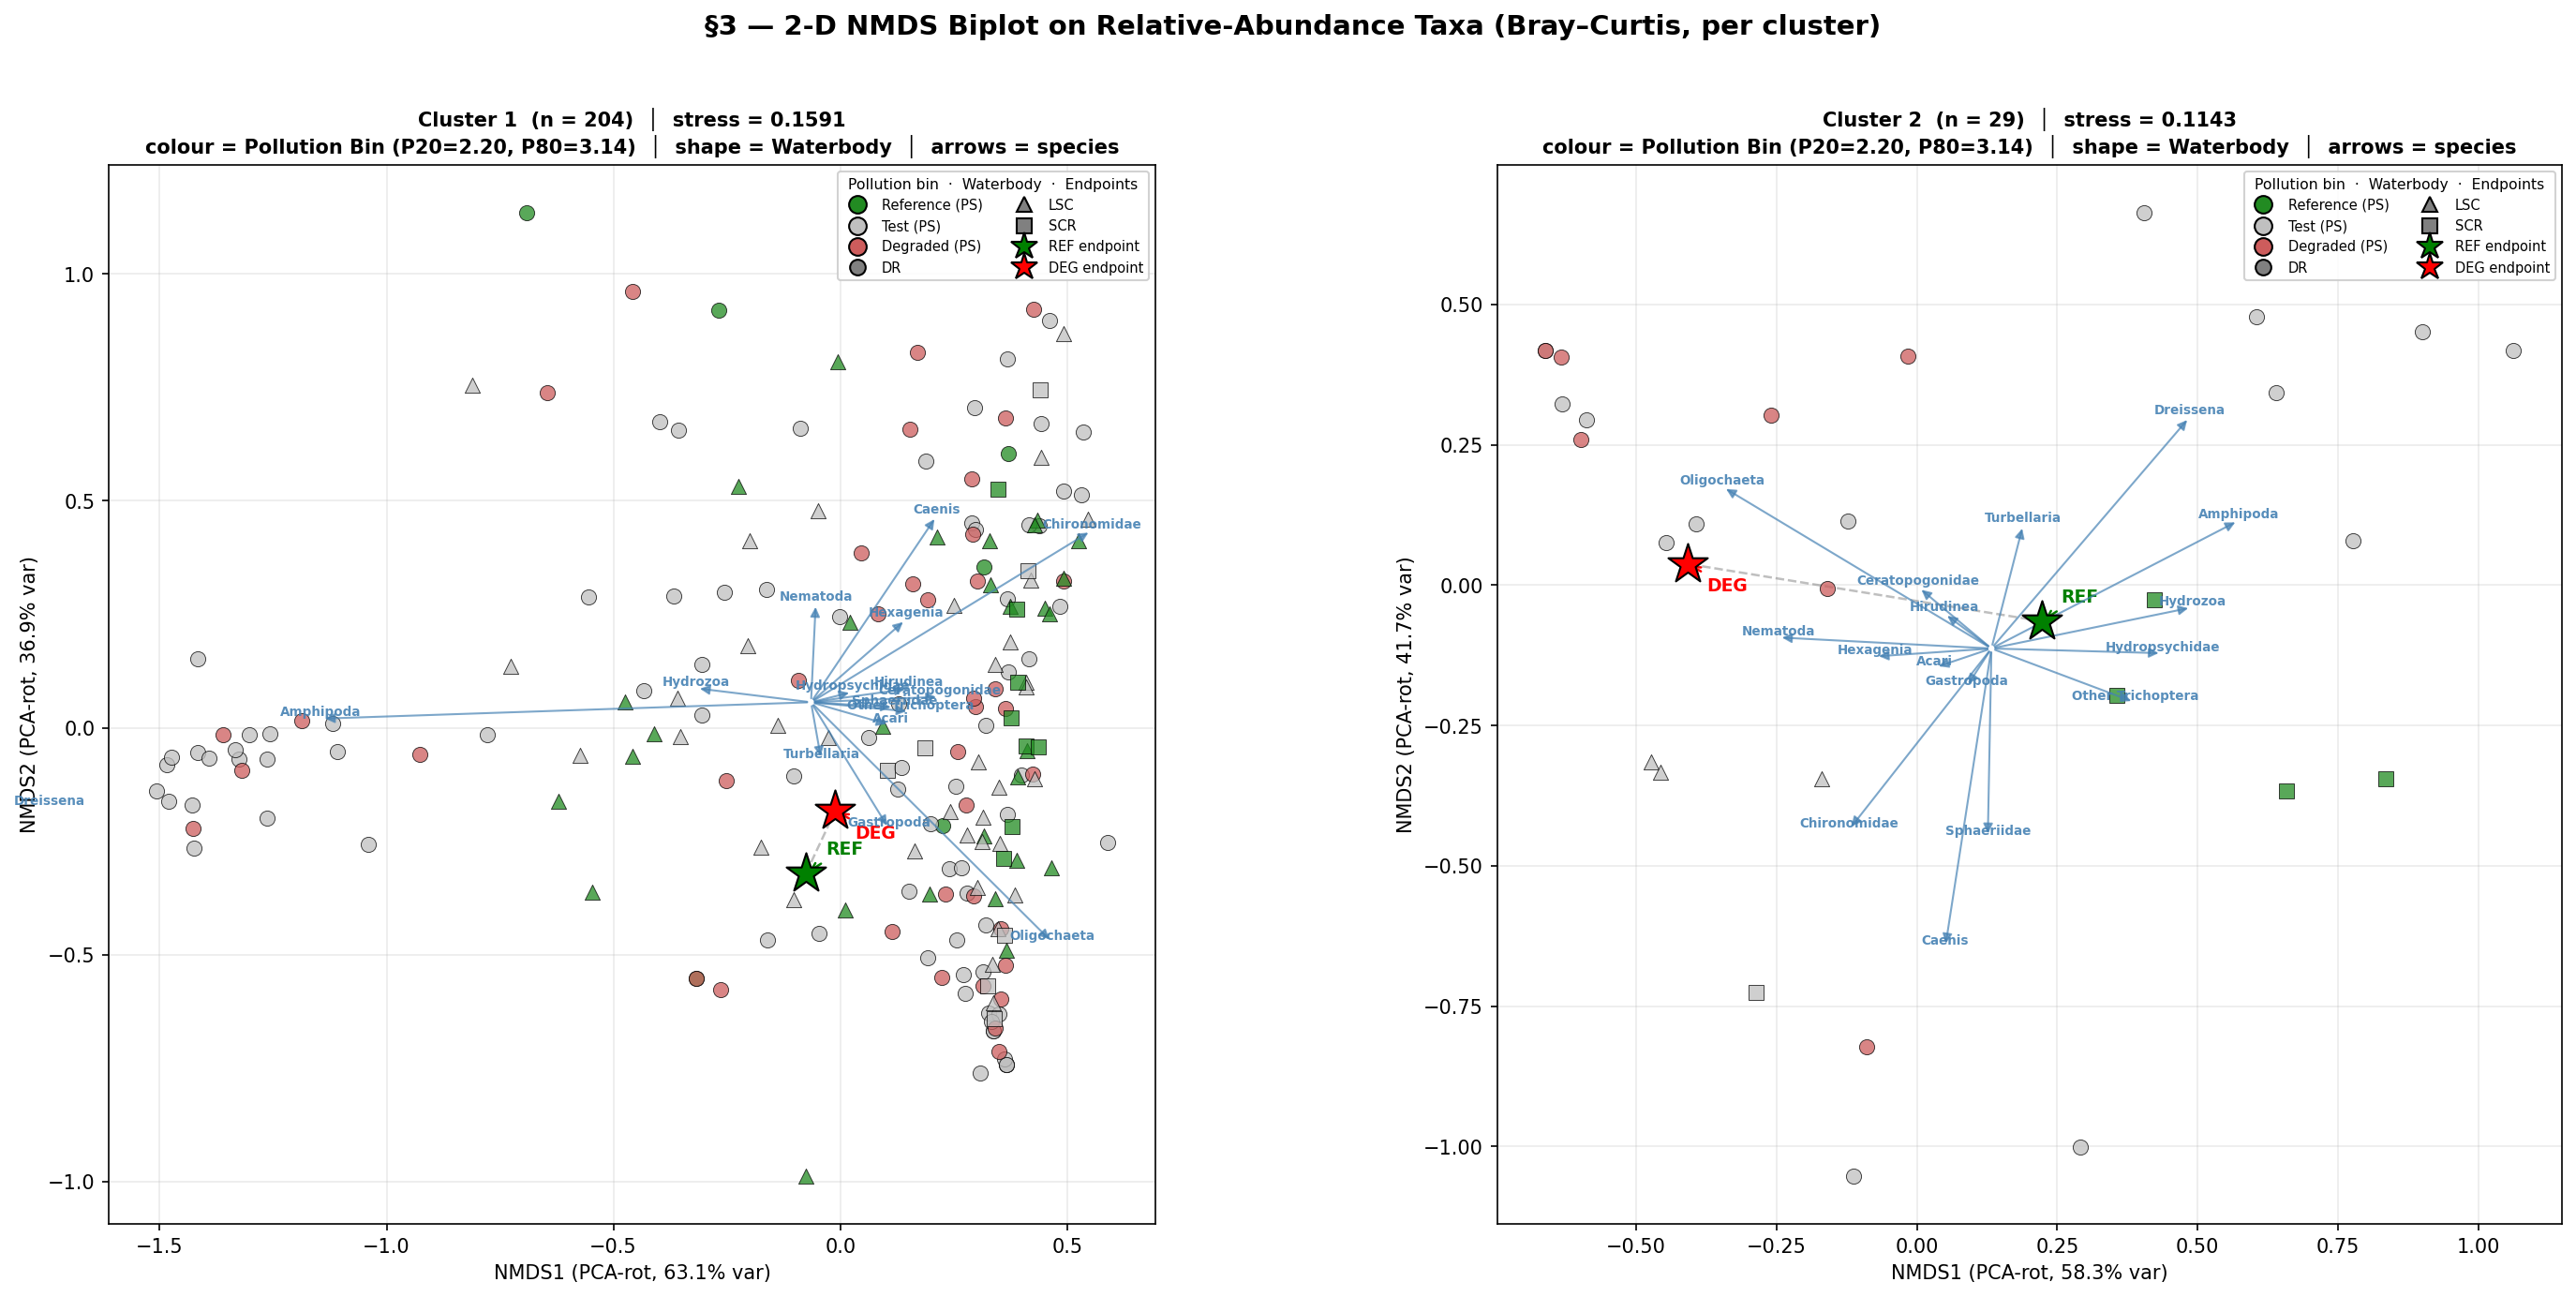


 Cluster      n      Stress      Var1      Var2
-----------------------------------------------------------------
       1    204     0.15914    63.1%    36.9%
       2     29     0.11429    58.3%    41.7%


In [3]:
# ── §3  Comprehensive NMDS Biplot ─────────────────────────────────────────────

# ── Pollution-level bins (based on OVERALL percentiles) ───────────────────────
ps_all = site_meta["Pollution_Score"]
p20 = np.percentile(ps_all, 20)
p80 = np.percentile(ps_all, 80)

def pollution_bin(ps_val):
    if ps_val <= p20:
        return "Reference"
    elif ps_val >= p80:
        return "Degraded"
    else:
        return "Test"

site_meta["PS_Bin"] = site_meta["Pollution_Score"].apply(pollution_bin)
bin_colors = {"Reference": "forestgreen", "Test": "silver", "Degraded": "indianred"}
bin_order  = ["Reference", "Test", "Degraded"]

print(f"Pollution-Score percentiles:  P20 = {p20:.3f},  P80 = {p80:.3f}")
print(site_meta["PS_Bin"].value_counts().reindex(bin_order))

# ── Waterbody → marker shape ─────────────────────────────────────────────────
wb_marker_map = {"DR": "o", "SCR": "s", "LSC": "^"}
wb_unique = sorted(site_meta["Waterbody"].dropna().unique())
# Fallback for any unexpected waterbody values
for wb in wb_unique:
    if wb not in wb_marker_map:
        wb_marker_map[wb] = "D"
print(f"Waterbody → marker: {wb_marker_map}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, n_clusters,
                         figsize=(10 * n_clusters, 9), dpi=150)
if n_clusters == 1:
    axs = [axs]

for ax, cl in zip(axs, clusters):
    res = nmds_results[cl]
    coords   = res["coords_df"]
    wa_df    = res["wa_df"]
    stress   = res["stress"]
    ref_lab  = res["ref_label"]
    deg_lab  = res["deg_label"]
    var_exp  = res["var_exp"]

    # Real sites only
    real_ids = [s for s in coords.index if s not in (ref_lab, deg_lab)]
    meta_cl  = site_meta.loc[real_ids]

    # ── 3a. Plot real sites: colour = pollution bin, shape = waterbody ─────
    for wb in wb_unique:
        for bn in bin_order:
            mask = (meta_cl["Waterbody"] == wb) & (meta_cl["PS_Bin"] == bn)
            ids = mask.index[mask]
            if len(ids) == 0:
                continue
            ax.scatter(
                coords.loc[ids, "NMDS1"],
                coords.loc[ids, "NMDS2"],
                marker=wb_marker_map[wb],
                s=60,
                c=bin_colors[bn],
                edgecolors="k",
                linewidths=0.45,
                alpha=0.75,
                zorder=3,
            )

    # ── 3b. Endpoints as large stars ──────────────────────────────────────
    ax.scatter(*coords.loc[ref_lab], marker="*", s=450,
               c="green", edgecolors="k", linewidths=1.0, zorder=6,
               label="REF endpoint")
    ax.scatter(*coords.loc[deg_lab], marker="*", s=450,
               c="red", edgecolors="k", linewidths=1.0, zorder=6,
               label="DEG endpoint")
    # annotate endpoints
    ax.annotate("REF", xy=tuple(coords.loc[ref_lab]),
                xytext=(10, 10), textcoords="offset points",
                fontsize=9, fontweight="bold", color="green",
                arrowprops=dict(arrowstyle="->", color="green", lw=1.2))
    ax.annotate("DEG", xy=tuple(coords.loc[deg_lab]),
                xytext=(10, -14), textcoords="offset points",
                fontsize=9, fontweight="bold", color="red",
                arrowprops=dict(arrowstyle="->", color="red", lw=1.2))

    # dashed line connecting endpoints (the "gradient axis")
    ax.plot([coords.loc[ref_lab, "NMDS1"], coords.loc[deg_lab, "NMDS1"]],
            [coords.loc[ref_lab, "NMDS2"], coords.loc[deg_lab, "NMDS2"]],
            ls="--", color="gray", lw=1.2, alpha=0.5, zorder=2)

    # ── 3c. Species scores — arrows from origin + text labels ─────────────
    origin = np.array([wa_df.values[:, 0].mean(), wa_df.values[:, 1].mean()])
    # Scale factor: arrows span ~40 % of the axis range for readability
    x_range = coords.loc[real_ids, "NMDS1"].max() - coords.loc[real_ids, "NMDS1"].min()
    y_range = coords.loc[real_ids, "NMDS2"].max() - coords.loc[real_ids, "NMDS2"].min()
    max_arrow = np.sqrt((wa_df["WA1"] - origin[0]).max()**2 +
                         (wa_df["WA2"] - origin[1]).max()**2) + 1e-12
    scale = 0.35 * max(x_range, y_range) / max_arrow

    texts = []
    for taxon in TAXA_COLUMNS:
        dx = (wa_df.loc[taxon, "WA1"] - origin[0]) * scale
        dy = (wa_df.loc[taxon, "WA2"] - origin[1]) * scale
        tip_x = origin[0] + dx
        tip_y = origin[1] + dy
        ax.annotate(
            "",
            xy=(tip_x, tip_y),
            xytext=(origin[0], origin[1]),
            arrowprops=dict(arrowstyle="-|>", color="steelblue",
                            lw=1.0, alpha=0.7),
            zorder=4,
        )
        t = ax.text(tip_x, tip_y, taxon,
                    fontsize=6.5, fontweight="bold", color="steelblue",
                    alpha=0.9, ha="center", va="bottom", zorder=5)
        texts.append(t)

    if adjust_text is not None:
        try:
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle="-", color="steelblue",
                                        lw=0.3, alpha=0.4))
        except Exception:
            pass

    # ── 3d. Legend ─────────────────────────────────────────────────────────
    # Pollution-bin handles
    h_bin = [Line2D([0], [0], marker="o", color="w",
                    markerfacecolor=bin_colors[bn], markeredgecolor="k",
                    markersize=9, label=f"{bn} (PS)")
             for bn in bin_order]

    # Waterbody handles
    h_wb = [Line2D([0], [0], marker=wb_marker_map[wb], color="w",
                   markerfacecolor="gray", markeredgecolor="k",
                   markersize=8, label=wb)
            for wb in wb_unique]

    # Endpoint handles
    h_ep = [
        Line2D([0], [0], marker="*", color="w", markerfacecolor="green",
               markeredgecolor="k", markersize=14, label="REF endpoint"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
               markeredgecolor="k", markersize=14, label="DEG endpoint"),
    ]

    all_handles = h_bin + h_wb + h_ep
    ax.legend(handles=all_handles, loc="best", fontsize=7,
              framealpha=0.88, ncol=2,
              title="Pollution bin  ·  Waterbody  ·  Endpoints",
              title_fontsize=7.5)

    # ── Axes & title ──────────────────────────────────────────────────────
    ax.set_xlabel(f"NMDS1 (PCA-rot, {var_exp[0]:.1%} var)", fontsize=10)
    ax.set_ylabel(f"NMDS2 (PCA-rot, {var_exp[1]:.1%} var)", fontsize=10)
    ax.set_title(
        f"Cluster {cl}  (n = {len(real_ids)})  │  stress = {stress:.4f}\n"
        f"colour = Pollution Bin (P20={p20:.2f}, P80={p80:.2f})  │  "
        f"shape = Waterbody  │  arrows = species",
        fontsize=10, fontweight="bold",
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)

fig.suptitle(
    "§3 — 2-D NMDS Biplot on Relative-Abundance Taxa (Bray–Curtis, per cluster)",
    fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# ── Quick summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Cluster':>8}  {'n':>5}  {'Stress':>10}  {'Var1':>8}  {'Var2':>8}")
print("-" * 65)
for cl in clusters:
    r = nmds_results[cl]
    n = len([s for s in r["coords_df"].index
             if s not in (r["ref_label"], r["deg_label"])])
    print(f"{cl:>8}  {n:>5}  {r['stress']:>10.5f}  "
          f"{r['var_exp'][0]:>7.1%}  {r['var_exp'][1]:>7.1%}")
print("=" * 65)

## §4 — ZCI Construction from NMDS (Adaptive Search)

### Goal
Compress the 2-D NMDS ordination into a **single community-condition score** (ZCI) per site, such that ZCI has a **significant negative relationship** with Pollution Score.

### Search space
We search over two dimensions:

| Parameter | Values | Rationale |
|-----------|--------|-----------|
| **N_EP** (endpoint size) | 3, 5, 8, 10, 15, 20 | More sites → more stable endpoints but less extreme |
| **ZCI method** | Distance, Projection | See below |

### ZCI methods

**Distance-based** — standard ratio of Euclidean distances in ordination space:
$$\text{ZCI}_i = \frac{d_{i,\text{deg}}}{d_{i,\text{ref}} + d_{i,\text{deg}}}$$
Drawback: sites far from *both* endpoints (perpendicular to the gradient) get ZCI ≈ 0.5, adding noise.

**Projection-based** — project each site onto the **line connecting DEG → REF**:
$$\mathbf{v} = \mathbf{x}_{\text{ref}} - \mathbf{x}_{\text{deg}}, \qquad \text{ZCI}_i = \frac{(\mathbf{x}_i - \mathbf{x}_{\text{deg}}) \cdot \mathbf{v}}{\mathbf{v} \cdot \mathbf{v}}$$
Advantage: ignores variation **perpendicular** to the pollution gradient, isolating the community signal along the gradient axis.

### Evaluation
For each (N_EP, method) combo we run a fast NMDS (n_init = 4), compute Pearson *r* of ZCI vs PS, and pick the most negative significant *r* per cluster.  The winner is then **re-run** with full quality (n_init = 10).

In [4]:
# ── §4  ZCI Grid Search ──────────────────────────────────────────────────────
import warnings
from scipy.stats import pearsonr, spearmanr, linregress

# ── ZCI formulae ──────────────────────────────────────────────────────────────
def _zci_dist(rc, ref, deg):
    """ZCI = d_deg / (d_ref + d_deg)"""
    dr = np.linalg.norm(rc - ref, axis=1)
    dd = np.linalg.norm(rc - deg, axis=1)
    return dd / (dr + dd + 1e-15)

def _zci_proj(rc, ref, deg):
    """ZCI = projection onto DEG→REF axis, normalised"""
    v = ref - deg
    return ((rc - deg) @ v) / (v @ v + 1e-15)

_methods = {"Distance": _zci_dist, "Projection": _zci_proj}

# ── Grid search ───────────────────────────────────────────────────────────────
_n_ep_grid = [3, 5, 8, 10, 15, 20]
_rows = []

print("Grid search: N_EP × ZCI method × cluster")
print(f"  N_EP      = {_n_ep_grid}")
print(f"  Methods   = {list(_methods)}")
print(f"  Clusters  = {clusters}\n")

for cl in clusters:
    idx_cl = site_meta.index[site_meta["Cluster"] == cl]
    mc = site_meta.loc[idx_cl]
    tc = taxa_relabd.loc[idx_cl]
    ps_v = mc["Pollution_Score"].values
    n = len(idx_cl)

    for nep in _n_ep_grid:
        if 2 * nep >= n:
            continue

        # ── endpoints ─────────────────────────────────────────────────────
        order = mc["Pollution_Score"].sort_values()
        ri, di = order.index[:nep], order.index[-nep:]
        rt = tc.loc[ri].mean(0)
        dt = tc.loc[di].mean(0)
        rl_ = f"_R{nep}_{cl}"; dl_ = f"_D{nep}_{cl}"

        ta = pd.concat([
            tc,
            pd.DataFrame([rt], index=[rl_], columns=TAXA_COLUMNS),
            pd.DataFrame([dt], index=[dl_], columns=TAXA_COLUMNS),
        ])
        bc = squareform(pdist(ta.values, metric="braycurtis"))

        # ── fast NMDS (n_init=4) ──────────────────────────────────────────
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mds = MDS(n_components=2, metric=False,
                      dissimilarity="precomputed",
                      max_iter=500, n_init=4, random_state=42,
                      normalized_stress="auto")
            ca = mds.fit_transform(bc)
        ca = PCA(n_components=2).fit_transform(ca)

        # flip NMDS1 if positively correlated with PS
        rm = np.array([i not in (rl_, dl_) for i in ta.index])
        if pearsonr(ca[rm, 0], ps_v)[0] > 0:
            ca[:, 0] *= -1

        rxy = ca[ta.index.get_loc(rl_)]
        dxy = ca[ta.index.get_loc(dl_)]
        rc  = ca[rm]

        for mn, mf in _methods.items():
            z = mf(rc, rxy, dxy)
            rp, pp = pearsonr(ps_v, z)
            rs, ps_ = spearmanr(ps_v, z)
            _rows.append(dict(Cluster=cl, N_EP=nep, Method=mn,
                              r_P=rp, p_P=pp, r_S=rs, p_S=ps_,
                              stress=mds.stress_))

_gdf = pd.DataFrame(_rows)

# ── Display ───────────────────────────────────────────────────────────────────
print("=" * 100)
print("  Grid Search Results — ZCI vs Pollution Score (Pearson r)")
print("=" * 100)
_fmt = _gdf.copy()
for c in ["r_P", "r_S"]:
    _fmt[c] = _fmt[c].map(lambda x: f"{x:+.4f}")
for c in ["p_P", "p_S"]:
    _fmt[c] = _fmt[c].map(lambda x: f"{x:.1e}")
_fmt["stress"] = _fmt["stress"].map(lambda x: f"{x:.5f}")
print(_fmt.to_string(index=False))

# ── Select best per cluster ───────────────────────────────────────────────────
print("\n" + "=" * 100)
print("  Best configuration per cluster  (most negative significant r)")
print("=" * 100)
best_cfg = {}
for cl in clusters:
    sub = _gdf[_gdf["Cluster"] == cl]
    sig = sub[sub["p_P"] < 0.05]
    if len(sig):
        bi = sig["r_P"].idxmin()
    else:
        bi = sub["r_P"].idxmin()
    best_cfg[cl] = _gdf.loc[bi]
    b = best_cfg[cl]
    star = ("***" if b.p_P < .001 else "**" if b.p_P < .01
            else "*" if b.p_P < .05 else "")
    print(f"  ★ Cluster {cl}: N_EP = {int(b.N_EP):>2d},  Method = {b.Method:<12s}  "
          f"r = {b.r_P:+.4f}{star}  (p = {b.p_P:.2e})")
print("=" * 100)

Grid search: N_EP × ZCI method × cluster
  N_EP      = [3, 5, 8, 10, 15, 20]
  Methods   = ['Distance', 'Projection']
  Clusters  = [np.int64(1), np.int64(2)]

  Grid Search Results — ZCI vs Pollution Score (Pearson r)
 Cluster  N_EP     Method     r_P     p_P     r_S     p_S  stress
       1     3   Distance +0.1262 7.2e-02 +0.1798 1.0e-02 0.16758
       1     3 Projection +0.1320 6.0e-02 +0.1416 4.3e-02 0.16758
       1     5   Distance +0.1002 1.5e-01 +0.1527 2.9e-02 0.16803
       1     5 Projection +0.1363 5.2e-02 +0.1575 2.5e-02 0.16803
       1     8   Distance +0.1282 6.8e-02 +0.1309 6.2e-02 0.16636
       1     8 Projection +0.1093 1.2e-01 +0.1291 6.6e-02 0.16636
       1    10   Distance -0.0021 9.8e-01 +0.0270 7.0e-01 0.16609
       1    10 Projection -0.0069 9.2e-01 -0.0097 8.9e-01 0.16609
       1    15   Distance -0.0776 2.7e-01 -0.1033 1.4e-01 0.16630
       1    15 Projection -0.1105 1.2e-01 -0.1344 5.5e-02 0.16630
       1    20   Distance -0.0852 2.3e-01 -0.0934 1.8e-

In [5]:
# ── §4a  Extended search ──────────────────────────────────────────────────────
#  1) Centroid-Projection: define direction by NMDS centroids of the N_EP
#     least/most-polluted *real* sites. No NMDS re-run needed (instant).
#  2) Larger N_EP (25-80) with standard NMDS re-run.
#  3) BC-Direct: use raw Bray-Curtis distances (no NMDS at all) as baseline.
# ─────────────────────────────────────────────────────────────────────────────
from scipy.spatial.distance import cdist

_ext_rows = []

# ── 1) Centroid-Projection on existing §2 NMDS (fast) ────────────────────────
for cl in clusters:
    res   = nmds_results[cl]
    cd    = res["coords_df"]
    rl_   = res["ref_label"]; dl_ = res["deg_label"]
    r_ids = [s for s in cd.index if s not in (rl_, dl_)]
    rc    = cd.loc[r_ids].values
    ps_v  = site_meta.loc[r_ids, "Pollution_Score"].values
    n     = len(r_ids)

    for nep in [3, 5, 10, 15, 20, 30, 40, 50, 60, 80]:
        if 2 * nep >= n:
            continue
        order   = np.argsort(ps_v)
        ref_c   = rc[order[:nep]].mean(0)
        deg_c   = rc[order[-nep:]].mean(0)
        v       = ref_c - deg_c
        proj    = ((rc - deg_c) @ v) / (v @ v + 1e-15)
        rp, pp  = pearsonr(ps_v, proj)
        rs, ps_ = spearmanr(ps_v, proj)
        _ext_rows.append(dict(Cluster=cl, N_EP=nep, Method="Centroid-Proj",
                              r_P=rp, p_P=pp, r_S=rs, p_S=ps_,
                              stress=res["stress"]))

# ── 2) Larger N_EP with NMDS re-run (Cluster 1 only, slow) ───────────────────
for nep in [25, 30, 40, 50]:
    for cl in clusters:
        idx_cl = site_meta.index[site_meta["Cluster"] == cl]
        mc = site_meta.loc[idx_cl]; tc = taxa_relabd.loc[idx_cl]
        ps_v = mc["Pollution_Score"].values; n = len(idx_cl)
        if 2 * nep >= n:
            continue
        order = mc["Pollution_Score"].sort_values()
        ri, di = order.index[:nep], order.index[-nep:]
        rt, dt = tc.loc[ri].mean(0), tc.loc[di].mean(0)
        rl_ = f"_R{nep}_{cl}"; dl_ = f"_D{nep}_{cl}"
        ta = pd.concat([
            tc,
            pd.DataFrame([rt], index=[rl_], columns=TAXA_COLUMNS),
            pd.DataFrame([dt], index=[dl_], columns=TAXA_COLUMNS),
        ])
        bc = squareform(pdist(ta.values, metric="braycurtis"))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mds = MDS(2, metric=False, dissimilarity="precomputed",
                      max_iter=500, n_init=4, random_state=42,
                      normalized_stress="auto")
            ca = mds.fit_transform(bc)
        ca = PCA(2).fit_transform(ca)
        rm = np.array([i not in (rl_, dl_) for i in ta.index])
        if pearsonr(ca[rm, 0], ps_v)[0] > 0:
            ca[:, 0] *= -1
        rxy = ca[ta.index.get_loc(rl_)]
        dxy = ca[ta.index.get_loc(dl_)]
        rc_ = ca[rm]
        for mn, mf in _methods.items():
            z = mf(rc_, rxy, dxy)
            rp, pp = pearsonr(ps_v, z); rs, ps_ = spearmanr(ps_v, z)
            _ext_rows.append(dict(Cluster=cl, N_EP=nep, Method=mn,
                                  r_P=rp, p_P=pp, r_S=rs, p_S=ps_,
                                  stress=mds.stress_))

# ── 3) BC-Direct (baseline, no NMDS) ─────────────────────────────────────────
for cl in clusters:
    idx_cl = site_meta.index[site_meta["Cluster"] == cl]
    mc = site_meta.loc[idx_cl]; tc = taxa_relabd.loc[idx_cl]
    ps_v = mc["Pollution_Score"].values; n = len(idx_cl)
    for nep in [3, 5, 10, 15, 20, 30, 40, 50]:
        if 2 * nep >= n:
            continue
        order = mc["Pollution_Score"].sort_values()
        ri, di = order.index[:nep], order.index[-nep:]
        rt = tc.loc[ri].mean(0).values.reshape(1, -1)
        dt = tc.loc[di].mean(0).values.reshape(1, -1)
        bc_r = cdist(rt, tc.values, metric="braycurtis")[0]
        bc_d = cdist(dt, tc.values, metric="braycurtis")[0]
        z = bc_d / (bc_r + bc_d + 1e-15)
        rp, pp = pearsonr(ps_v, z); rs, ps_ = spearmanr(ps_v, z)
        _ext_rows.append(dict(Cluster=cl, N_EP=nep, Method="BC-Direct",
                              r_P=rp, p_P=pp, r_S=rs, p_S=ps_,
                              stress=np.nan))

_ext_df = pd.DataFrame(_ext_rows)
_all_df = pd.concat([_gdf, _ext_df], ignore_index=True)

# ── Display extended results ──────────────────────────────────────────────────
for cl in clusters:
    sub = _ext_df[_ext_df["Cluster"] == cl].copy()
    sub["r_P"] = sub["r_P"].map(lambda x: f"{x:+.4f}")
    sub["p_P"] = sub["p_P"].map(lambda x: f"{x:.1e}")
    print(f"\nCluster {cl} — Extended search:")
    print(sub[["N_EP", "Method", "r_P", "p_P"]].to_string(index=False))

# ── Update best per cluster from ALL results ──────────────────────────────────
print("\n" + "=" * 90)
print("  Updated Best Configuration per Cluster  (all methods)")
print("=" * 90)
for cl in clusters:
    sub = _all_df[_all_df["Cluster"] == cl]
    sig = sub[sub["p_P"] < 0.05]
    if len(sig):
        bi = sig["r_P"].idxmin()
    else:
        bi = sub["r_P"].idxmin()
    best_cfg[cl] = _all_df.loc[bi]
    b = best_cfg[cl]
    star = ("***" if b.p_P < .001 else "**" if b.p_P < .01
            else "*" if b.p_P < .05 else "")
    print(f"  ★ Cluster {cl}: N_EP = {int(b.N_EP):>2d},  "
          f"Method = {b.Method:<15s}  r = {b.r_P:+.4f}{star}  "
          f"(p = {b.p_P:.2e})")
print("=" * 90)


Cluster 1 — Extended search:
 N_EP        Method     r_P     p_P
    3 Centroid-Proj +0.1002 1.5e-01
    5 Centroid-Proj +0.0382 5.9e-01
   10 Centroid-Proj +0.0321 6.5e-01
   15 Centroid-Proj -0.1007 1.5e-01
   20 Centroid-Proj -0.1051 1.3e-01
   30 Centroid-Proj -0.1028 1.4e-01
   40 Centroid-Proj -0.1031 1.4e-01
   50 Centroid-Proj -0.1032 1.4e-01
   60 Centroid-Proj -0.0993 1.6e-01
   80 Centroid-Proj -0.1046 1.4e-01
   25      Distance -0.0847 2.3e-01
   25    Projection -0.1092 1.2e-01
   30      Distance -0.0686 3.3e-01
   30    Projection -0.1104 1.2e-01
   40      Distance -0.0794 2.6e-01
   40    Projection -0.1104 1.2e-01
   50      Distance -0.0876 2.1e-01
   50    Projection -0.1094 1.2e-01
    3     BC-Direct -0.0937 1.8e-01
    5     BC-Direct -0.0960 1.7e-01
   10     BC-Direct -0.1669 1.7e-02
   15     BC-Direct -0.2820 4.4e-05
   20     BC-Direct -0.1936 5.5e-03
   30     BC-Direct -0.1904 6.4e-03
   40     BC-Direct -0.2247 1.2e-03
   50     BC-Direct -0.1786 1.1e-0

Cluster 1:  N_EP=15,  Method=BC-Direct
  Pearson r  = -0.2820***  (p = 4.37e-05)
  Spearman ρ = -0.2758
Cluster 2:  N_EP=3,  Method=BC-Direct
  Pearson r  = -0.4864**  (p = 7.47e-03)
  Spearman ρ = -0.4249


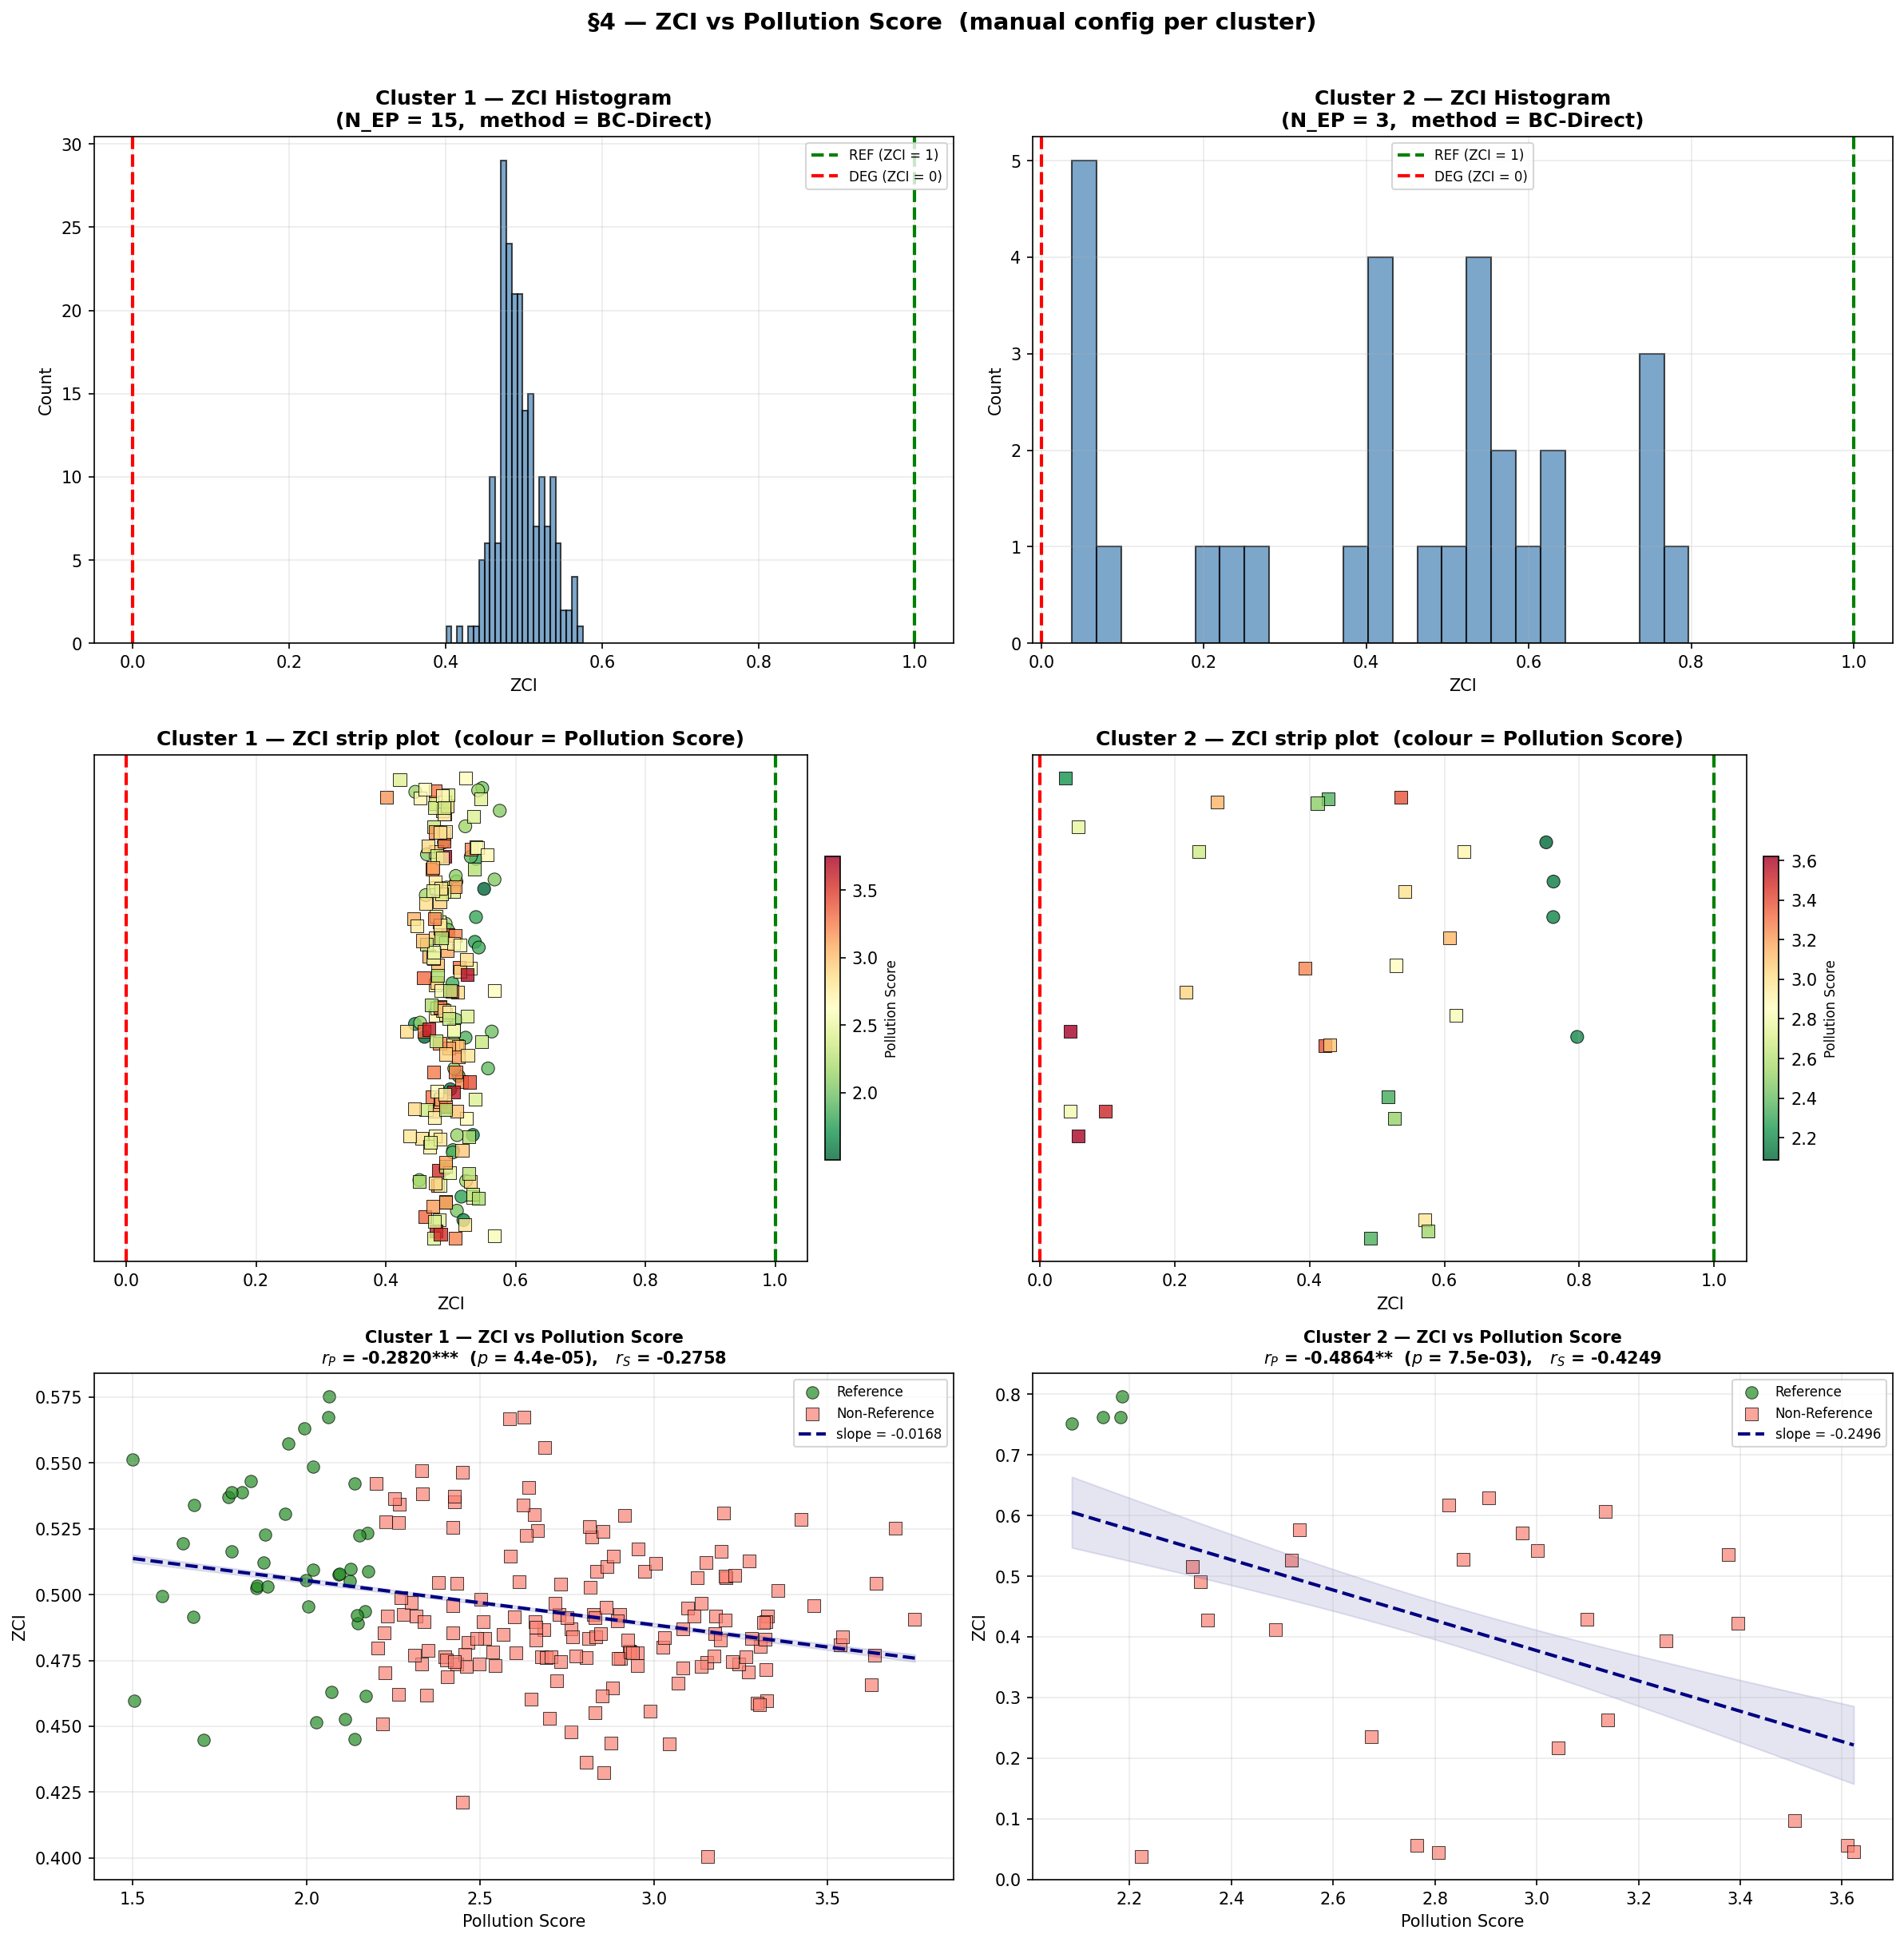


  Final ZCI Summary

  Cluster 1:  N_EP = 15,  Method = BC-Direct
    ZCI range:  [0.400, 0.575]
    ZCI mean:   0.495 ± 0.029
    Pearson  r = -0.2820***  (p = 4.37e-05)
    Spearman ρ = -0.2758
    NMDS stress (§2) = 0.15914

  Cluster 2:  N_EP = 3,  Method = BC-Direct
    ZCI range:  [0.038, 0.797]
    ZCI mean:   0.426 ± 0.240
    Pearson  r = -0.4864**  (p = 7.47e-03)
    Spearman ρ = -0.4249
    NMDS stress (§2) = 0.11429


In [12]:
# ── §4b  Final ZCI — compute with MANUAL config & visualize ───────────────────
#
#  ╔═══════════════════════════════════════════════════════════════════════════╗
#  ║  USER CONFIG — change N_EP and Method per cluster here                  ║
#  ║  Available methods: "BC-Direct", "Distance", "Projection",             ║
#  ║                     "Centroid-Proj"                                     ║
#  ╚═══════════════════════════════════════════════════════════════════════════╝
USER_CFG = {
    1: {"N_EP": 15, "Method": "BC-Direct"},
    2: {"N_EP":  3, "Method": "BC-Direct"},
}

final_zci = {}  # cl -> dict

for cl in clusters:
    cfg    = USER_CFG[cl]
    nep    = cfg["N_EP"]
    method = cfg["Method"]

    idx_cl = site_meta.index[site_meta["Cluster"] == cl]
    mc = site_meta.loc[idx_cl]
    tc = taxa_relabd.loc[idx_cl]
    ps_v = mc["Pollution_Score"].values

    # ── Endpoints ─────────────────────────────────────────────────────────
    order = mc["Pollution_Score"].sort_values()
    ri, di = order.index[:nep], order.index[-nep:]
    rt = tc.loc[ri].mean(0)
    dt = tc.loc[di].mean(0)

    # ── Compute ZCI ───────────────────────────────────────────────────────
    if method == "BC-Direct":
        # Use raw Bray-Curtis distances — no dimensionality reduction
        bc_ref = cdist(rt.values.reshape(1, -1), tc.values,
                       metric="braycurtis")[0]
        bc_deg = cdist(dt.values.reshape(1, -1), tc.values,
                       metric="braycurtis")[0]
        zci_v = bc_deg / (bc_ref + bc_deg + 1e-15)
        zci_s = pd.Series(zci_v, index=idx_cl, name="ZCI")
        stress_ = np.nan  # not applicable

        # For visualisation we still use the §2 NMDS coordinates
        coords_for_plot = nmds_results[cl]["coords_df"]
        wa_for_plot     = nmds_results[cl]["wa_df"]
        ve_for_plot     = nmds_results[cl]["var_exp"]
        stress_nmds     = nmds_results[cl]["stress"]
        rl_plot = nmds_results[cl]["ref_label"]
        dl_plot = nmds_results[cl]["deg_label"]

    elif method == "Centroid-Proj":
        # Project onto centroid-defined axis in existing §2 NMDS space
        res   = nmds_results[cl]
        cd    = res["coords_df"]
        rl_   = res["ref_label"]; dl_ = res["deg_label"]
        r_ids = [s for s in cd.index if s not in (rl_, dl_)]
        rc_   = cd.loc[r_ids].values
        order_idx = np.argsort(ps_v)
        ref_c = rc_[order_idx[:nep]].mean(0)
        deg_c = rc_[order_idx[-nep:]].mean(0)
        v     = ref_c - deg_c
        zci_v = ((rc_ - deg_c) @ v) / (v @ v + 1e-15)
        zci_s = pd.Series(zci_v, index=r_ids, name="ZCI")
        stress_ = res["stress"]

        coords_for_plot = cd
        wa_for_plot     = res["wa_df"]
        ve_for_plot     = res["var_exp"]
        stress_nmds     = res["stress"]
        rl_plot = rl_; dl_plot = dl_

    else:
        # Re-run NMDS with full quality (n_init=10) for Distance / Projection
        rl_ = f"_REF_BEST_{cl}"; dl_ = f"_DEG_BEST_{cl}"
        ta = pd.concat([
            tc,
            pd.DataFrame([rt], index=[rl_], columns=TAXA_COLUMNS),
            pd.DataFrame([dt], index=[dl_], columns=TAXA_COLUMNS),
        ])
        bc = squareform(pdist(ta.values, metric="braycurtis"))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mds = MDS(2, metric=False, dissimilarity="precomputed",
                      max_iter=1000, n_init=10, random_state=42,
                      normalized_stress="auto")
            ca = mds.fit_transform(bc)
        pca_ = PCA(2).fit(ca)
        ca   = pca_.transform(ca)
        ve   = pca_.explained_variance_ratio_
        rm   = np.array([i not in (rl_, dl_) for i in ta.index])
        if pearsonr(ca[rm, 0], ps_v)[0] > 0:
            ca[:, 0] *= -1
        coords_df = pd.DataFrame(ca, index=ta.index, columns=["NMDS1", "NMDS2"])
        rxy = coords_df.loc[rl_].values
        dxy = coords_df.loc[dl_].values
        real_sites = [s for s in coords_df.index if s not in (rl_, dl_)]
        rc = coords_df.loc[real_sites].values

        if method == "Distance":
            zci_v = _zci_dist(rc, rxy, dxy)
        else:
            zci_v = _zci_proj(rc, rxy, dxy)
        zci_s = pd.Series(zci_v, index=real_sites, name="ZCI")
        stress_ = mds.stress_

        coords_for_plot = coords_df
        wa_for_plot = None  # will recompute below
        ve_for_plot = ve
        stress_nmds = mds.stress_
        rl_plot = rl_; dl_plot = dl_

        # WA species scores
        ab = tc.loc[real_sites].values
        sc = coords_df.loc[real_sites].values
        cs = ab.sum(0); cs[cs == 0] = 1e-12
        wa_for_plot = pd.DataFrame(
            (ab.T @ sc) / cs[:, None],
            index=TAXA_COLUMNS, columns=["WA1", "WA2"])

    rp, pp = pearsonr(ps_v, zci_s.loc[idx_cl].values)
    rs, ps_ = spearmanr(ps_v, zci_s.loc[idx_cl].values)

    final_zci[cl] = dict(
        zci=zci_s, stress=stress_, method=method, n_ep=nep,
        r_P=rp, p_P=pp, r_S=rs, p_S=ps_,
        coords_for_plot=coords_for_plot,
        wa_for_plot=wa_for_plot,
        ve_for_plot=ve_for_plot,
        stress_nmds=stress_nmds,
        ref_label=rl_plot,
        deg_label=dl_plot,
        ref_ids=ri, deg_ids=di,
    )

    star = ("***" if pp < .001 else "**" if pp < .01
            else "*" if pp < .05 else "")
    print(f"Cluster {cl}:  N_EP={nep},  Method={method}")
    print(f"  Pearson r  = {rp:+.4f}{star}  (p = {pp:.2e})")
    print(f"  Spearman ρ = {rs:+.4f}")


# ══════════════════════════════════════════════════════════════════════════════
# Visualisation: 3 rows × n_clusters
#   Row 1 — ZCI histogram
#   Row 2 — ZCI strip coloured by PS
#   Row 3 — ZCI vs Pollution Score scatter + regression
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, n_clusters, figsize=(8 * n_clusters, 16), dpi=150)
if n_clusters == 1:
    axes = axes.reshape(3, 1)

for ci, cl in enumerate(clusters):
    fz  = final_zci[cl]
    zci = fz["zci"]
    mc  = site_meta.loc[zci.index]
    ps  = mc["Pollution_Score"]
    ref_mask = mc["Is_Reference"] == 1

    # ── Row 1: Histogram ──────────────────────────────────────────────────
    ax1 = axes[0, ci]
    ax1.hist(zci, bins=25, color="steelblue", edgecolor="k", alpha=0.7)
    ax1.axvline(1.0, color="green", ls="--", lw=2, label="REF (ZCI = 1)")
    ax1.axvline(0.0, color="red",   ls="--", lw=2, label="DEG (ZCI = 0)")
    ax1.set_xlabel("ZCI")
    ax1.set_ylabel("Count")
    ax1.set_title(
        f"Cluster {cl} — ZCI Histogram\n"
        f"(N_EP = {fz['n_ep']},  method = {fz['method']})",
        fontweight="bold")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.25)

    # ── Row 2: Strip plot coloured by PS ──────────────────────────────────
    ax2 = axes[1, ci]
    ax2.scatter(
        zci[ref_mask.index[ref_mask]],
        np.random.default_rng(42).uniform(-0.3, 0.3, ref_mask.sum()),
        c=ps[ref_mask], cmap="RdYlGn_r", marker="o",
        s=60, edgecolors="k", linewidths=0.5, alpha=0.8,
        vmin=ps.min(), vmax=ps.max())
    sc2 = ax2.scatter(
        zci[ref_mask.index[~ref_mask]],
        np.random.default_rng(43).uniform(-0.3, 0.3, (~ref_mask).sum()),
        c=ps[~ref_mask], cmap="RdYlGn_r", marker="s",
        s=60, edgecolors="k", linewidths=0.5, alpha=0.8,
        vmin=ps.min(), vmax=ps.max())
    ax2.axvline(1.0, color="green", ls="--", lw=2)
    ax2.axvline(0.0, color="red",   ls="--", lw=2)
    ax2.set_xlabel("ZCI")
    ax2.set_yticks([])
    ax2.set_title(
        f"Cluster {cl} — ZCI strip plot  (colour = Pollution Score)",
        fontweight="bold")
    cb = fig.colorbar(sc2, ax=ax2, shrink=0.6, pad=0.02)
    cb.set_label("Pollution Score", fontsize=8)
    ax2.grid(axis="x", alpha=0.25)

    # ── Row 3: ZCI vs Pollution Score with regression ─────────────────────
    ax3 = axes[2, ci]
    ax3.scatter(
        ps[ref_mask], zci[ref_mask.index[ref_mask]],
        c="forestgreen", marker="o", s=55, edgecolors="k",
        linewidths=0.5, alpha=0.7, label="Reference")
    ax3.scatter(
        ps[~ref_mask], zci[ref_mask.index[~ref_mask]],
        c="salmon", marker="s", s=55, edgecolors="k",
        linewidths=0.5, alpha=0.7, label="Non-Reference")

    # regression line + 95 % CI band
    lr = linregress(ps, zci.loc[ps.index])
    xf = np.linspace(ps.min(), ps.max(), 200)
    yf = lr.slope * xf + lr.intercept
    ax3.plot(xf, yf, "--", color="navy", lw=2,
             label=f"slope = {lr.slope:.4f}")
    n_s = len(ps); xm = ps.mean()
    se = lr.stderr * np.sqrt(
        1 / n_s + (xf - xm) ** 2 / np.sum((ps - xm) ** 2))
    ax3.fill_between(xf, yf - 1.96 * se, yf + 1.96 * se,
                     color="navy", alpha=0.10)

    star = ("***" if fz["p_P"] < .001 else "**" if fz["p_P"] < .01
            else "*" if fz["p_P"] < .05 else "")
    ax3.set_xlabel("Pollution Score")
    ax3.set_ylabel("ZCI")
    ax3.set_title(
        f"Cluster {cl} — ZCI vs Pollution Score\n"
        f"$r_P$ = {fz['r_P']:.4f}{star}  "
        f"($p$ = {fz['p_P']:.1e}),   $r_S$ = {fz['r_S']:.4f}",
        fontweight="bold", fontsize=10)
    ax3.legend(fontsize=8, loc="best")
    ax3.grid(alpha=0.25)

fig.suptitle(
    "§4 — ZCI vs Pollution Score  (manual config per cluster)",
    fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  Final ZCI Summary")
print("=" * 80)
for cl in clusters:
    fz  = final_zci[cl]
    zci = fz["zci"]
    star = ("***" if fz["p_P"] < .001 else "**" if fz["p_P"] < .01
            else "*" if fz["p_P"] < .05 else "")
    print(f"\n  Cluster {cl}:  N_EP = {fz['n_ep']},  Method = {fz['method']}")
    print(f"    ZCI range:  [{zci.min():.3f}, {zci.max():.3f}]")
    print(f"    ZCI mean:   {zci.mean():.3f} ± {zci.std():.3f}")
    print(f"    Pearson  r = {fz['r_P']:+.4f}{star}  (p = {fz['p_P']:.2e})")
    print(f"    Spearman ρ = {fz['r_S']:+.4f}")
    if not np.isnan(fz['stress_nmds']):
        print(f"    NMDS stress (§2) = {fz['stress_nmds']:.5f}")
print("=" * 80)